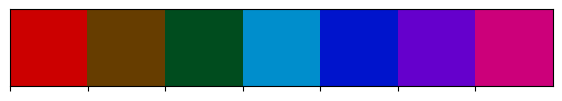

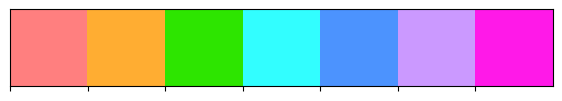

In [1]:
import os
import sys
import numpy as np
import random
import matplotlib.pylab as plt

SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.policy_analysis import discount_episode_reward, sum_ep_timesteps

In [110]:
gamma = 0.99
n_seeds = 10
goal_reward = 1
timesteps_freq = int(1e5)
plot_mean = True
main_dir = "../cc_general_models/9_9/Penalty/reward_model/env_0.0/eps_decay/goal_1_fire_10_adam_itr_100/q_lr_0.0005/reward_lr_0.001/"

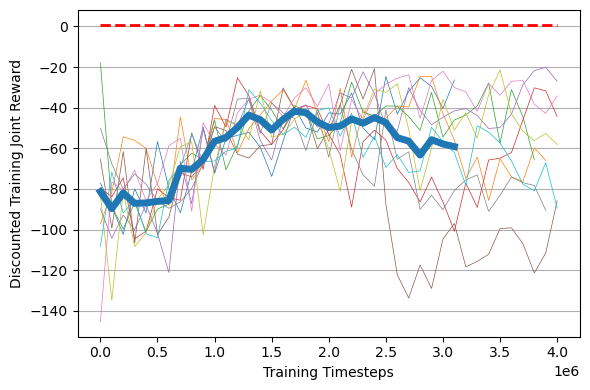

In [111]:
fig = plt.figure(figsize=(6, 4))
max_x_axis = 0
ep_window = 10
seeds_y_axis = []
for seed in range(n_seeds):
    train_reward = np.load(main_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
    ep_reward, ep_length = discount_episode_reward(train_reward, gamma=gamma)
    ep_timesteps_sum = sum_ep_timesteps(ep_length)
    x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
    max_x_axis = np.max(x_axis) if np.max(x_axis) > max_x_axis else max_x_axis
    y_axis = []
    count = 0
    for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]) + 1, timesteps_freq):
        ind = np.where(ep_timesteps_sum > timestep)[0][0]
        value = np.mean(ep_reward[ind - ep_window: ind]) if ind > ep_window else ep_reward[ind]
        y_axis.append(value)
        count += 1
    plt.plot(x_axis, y_axis, lw=0.5 if plot_mean else 2, label="seed={}".format(seed))
    seeds_y_axis.append(y_axis)
if plot_mean:
    lenghts = [len(l) for l in seeds_y_axis]
    np.save(main_dir + "/training_reward_mean_over_seeds.npy", np.mean(np.array([l[:min(lenghts)] for l in seeds_y_axis]), 0))
    plt.plot(x_axis[:min(lenghts)], np.mean(np.array([l[:min(lenghts)] for l in seeds_y_axis]), 0), lw=5)
plt.hlines(goal_reward * gamma** 23, 0, max_x_axis, color="r", lw=2, linestyle="--", label="Optimal")
plt.xlabel("Training Timesteps")
plt.ylabel("Discounted Training Joint Reward")
plt.grid(axis="y")
# plt.ylim(-200, 1)
# plt.xlim(2e6, )
# plt.legend()
plt.tight_layout()
# fig.savefig(main_dir + "/training_curve_ep_window_{}_all_seeds.png".format(ep_window), dpi=300) 

In [49]:
n_walls = 2
a = np.random.randint(0, 3, (3, 9, 9))
new_shape = list(a.shape)
new_shape[0] += 1
new_shape[1] += 2 * n_walls
new_shape[2] += 2 * n_walls
a_shape = tuple(new_shape)
a_shape

(4, 13, 13)

In [50]:
new_a = np.zeros(a_shape)
new_a[:-1, n_walls:-n_walls, n_walls:-n_walls] = a.copy()
new_a[-1, :n_walls, :] = 1
new_a[-1, :, :n_walls] = 1
new_a[-1, -n_walls:, :] = 1
new_a[-1, :, -n_walls:] = 1


In [51]:
new_a[0]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 1., 2., 0., 2., 2., 1., 1., 2., 0., 0.],
       [0., 0., 2., 1., 0., 0., 0., 2., 2., 2., 0., 0., 0.],
       [0., 0., 2., 2., 1., 0., 1., 2., 2., 1., 0., 0., 0.],
       [0., 0., 2., 0., 2., 2., 2., 1., 2., 0., 1., 0., 0.],
       [0., 0., 1., 1., 1., 2., 1., 2., 0., 1., 0., 0., 0.],
       [0., 0., 0., 2., 1., 1., 2., 1., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0.],
       [0., 0., 2., 0., 2., 0., 2., 1., 0., 2., 0., 0., 0.],
       [0., 0., 2., 2., 2., 2., 2., 1., 2., 1., 2., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [22]:
n_plant = 3
obs_shape = (4, 6, 6)
agent_pos = [0, 4]
plants_pos = np.concatenate((np.random.randint(0, 5, size=(3, 1)), np.random.randint(0, 5, size=(3, 1))), 1)
# print(random.choice([i for i in range(0, 5) if i not in [agent_pos[0]]]))
print(plants_pos)

[[3 4]
 [4 1]
 [3 2]]


In [29]:
grid = np.zeros(obs_shape)
grid[-1, plants_pos[:, 0], plants_pos[:, 1]] = np.random.choice([0, 0.5, 1], size=(n_plant, ))
grid[0, agent_pos[0], agent_pos[1]] = 1
grid[-1, :, :]

array([[0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0. , 1. , 0. ],
       [0. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. ]])

In [66]:
grid[-1, :, :]


array([[0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [6]:
agent_pos = [3,0]
plants_pos = np.array(([[1, 0], [0, 0]]))

np.any(np.all(agent_pos == plants_pos, axis=1))

False